In [1]:
import json
from itertools import product
import os

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
stats_data_fp = 'data/150_10_stats.json'
n = 150

stats_data = {}
with open(stats_data_fp, 'r') as sd:
    stats_data = json.loads(sd.read())

In [23]:
sns.set_theme(font="serif", font_scale=1.2)

def plot_heat_map(data, title, min, sc, ho):
    x_tick_labels = sc
    y_tick_labels = ho

    fig, ax = plt.subplots(figsize=(10, 10))
    ax = sns.heatmap(data, vmin = min,  cmap = 'YlOrBr', xticklabels = x_tick_labels, yticklabels = y_tick_labels, linewidth=0.5, cbar=False, annot=True, ax=ax)
#    plt.title(title)
    ax.set_xlabel('Proportion of Homophily Agents')
    ax.set_ylabel('Proportion of Social Capital Agents')

    ax.invert_yaxis()
    ax.tick_params(left=True, bottom=True)
    
    fig_dir = f'figures/heatmaps/size{n}'
    if not os.path.isdir(fig_dir):
        os.mkdir(fig_dir)
    title_save = f'{fig_dir}/{title}.pdf'
    plt.show()
    plt.savefig(title_save, dpi = 300)
#    plt.close('all')

    print('for dataset', title, 'data max', np.max(data), 'data min', np.min(data))

Average degree corners 7.22 9.51 7.71 9.5


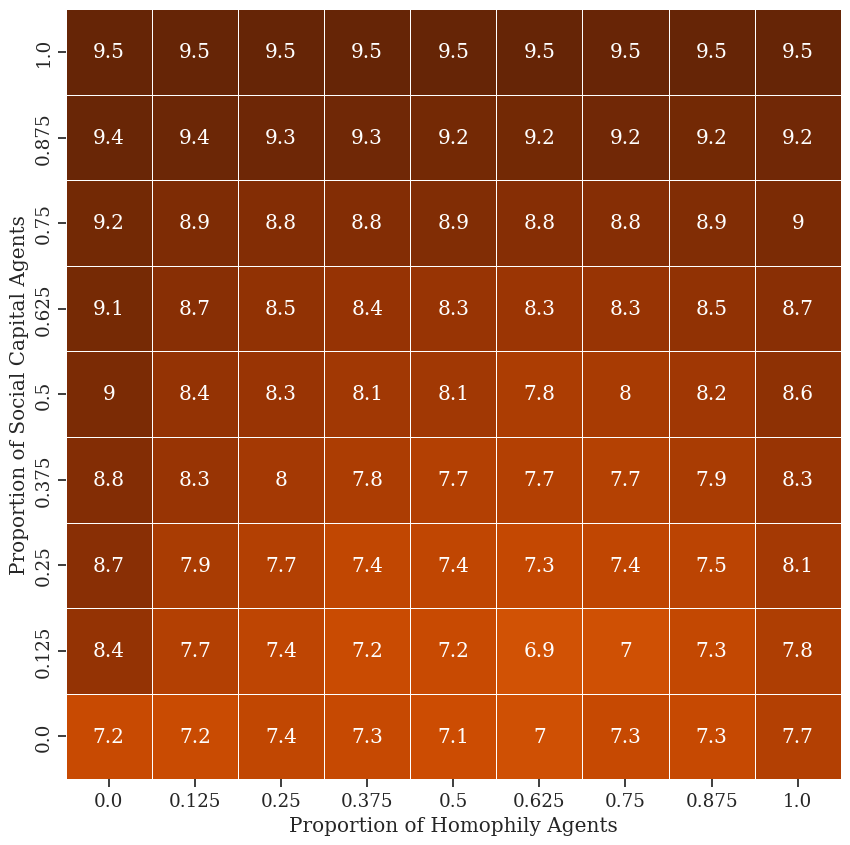

for dataset Average degree data max 9.51 data min 6.94
Degree assortativity corners 0.1 -0.02 0.31 -0.05


<Figure size 640x480 with 0 Axes>

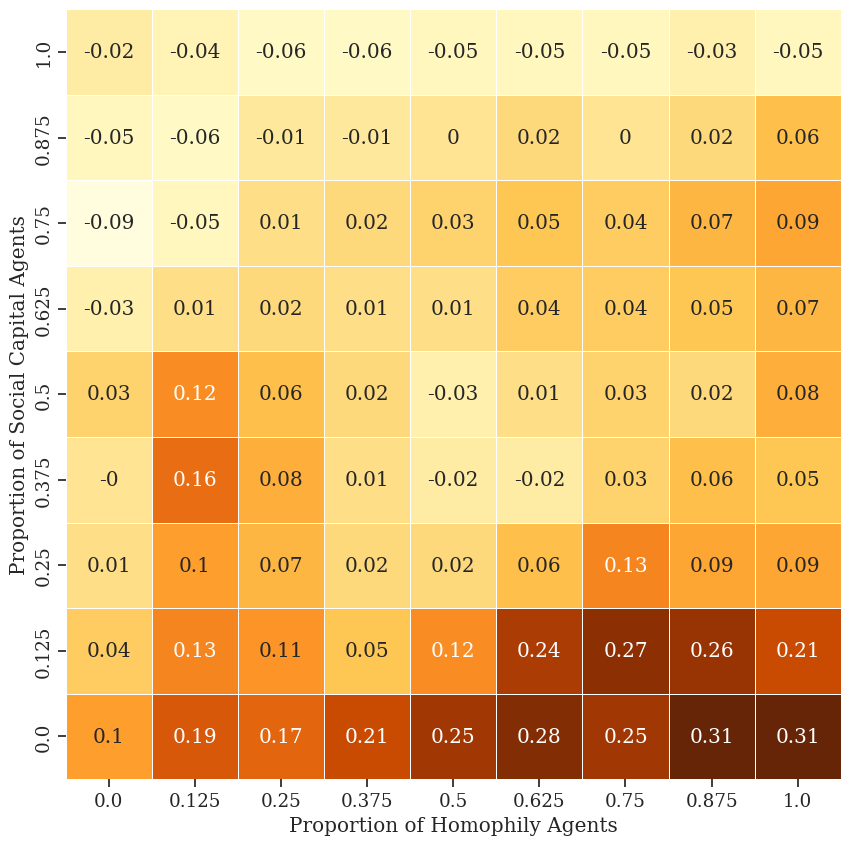

for dataset Degree assortativity data max 0.31 data min -0.09
Degree standard deviation corners 1.89 0.51 2.02 0.53


<Figure size 640x480 with 0 Axes>

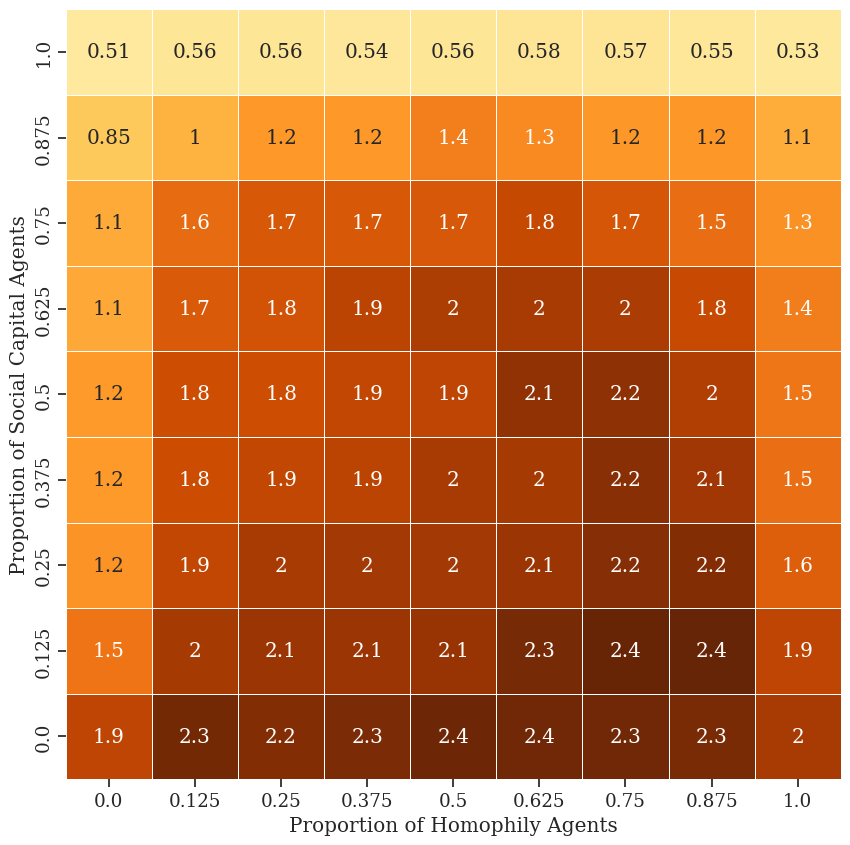

for dataset Degree standard deviation data max 2.41 data min 0.51
Degree Gini coefficient corners 0.14 0.03 0.14 0.03


<Figure size 640x480 with 0 Axes>

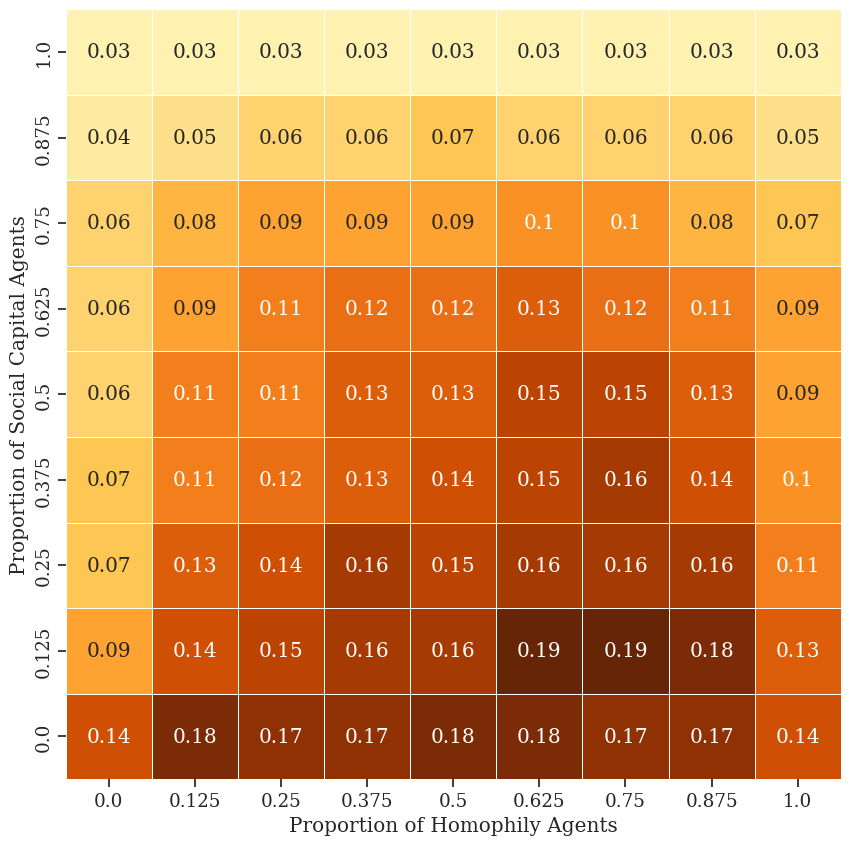

for dataset Degree Gini coefficient data max 0.19 data min 0.03
Average path length corners 3.1 2.44 2.32 2.44


<Figure size 640x480 with 0 Axes>

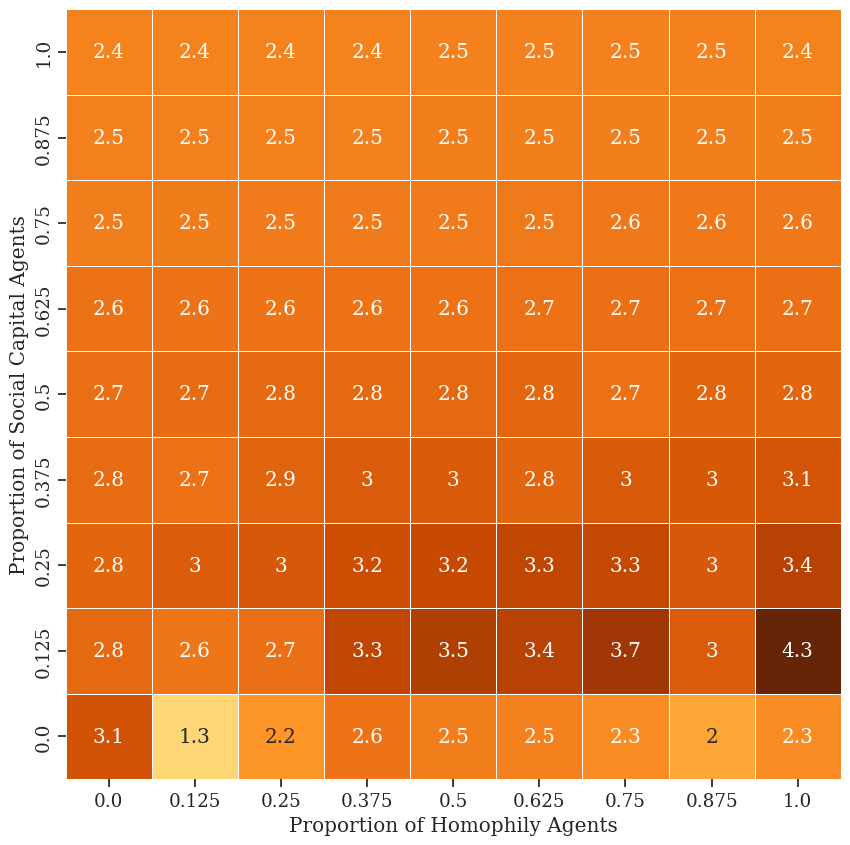

for dataset Average path length data max 4.28 data min 1.29
Diameter corners 6.0 4.0 5.07 4.0


<Figure size 640x480 with 0 Axes>

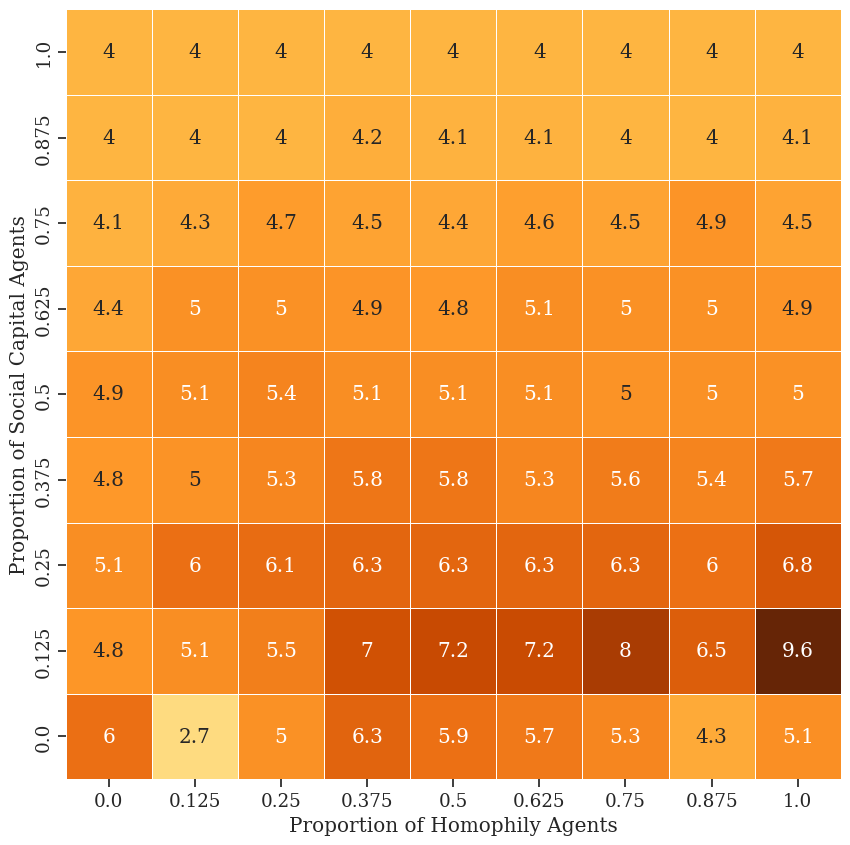

for dataset Diameter data max 9.55 data min 2.69
Clustering coefficient corners 0.25 0.0 0.81 0.0


<Figure size 640x480 with 0 Axes>

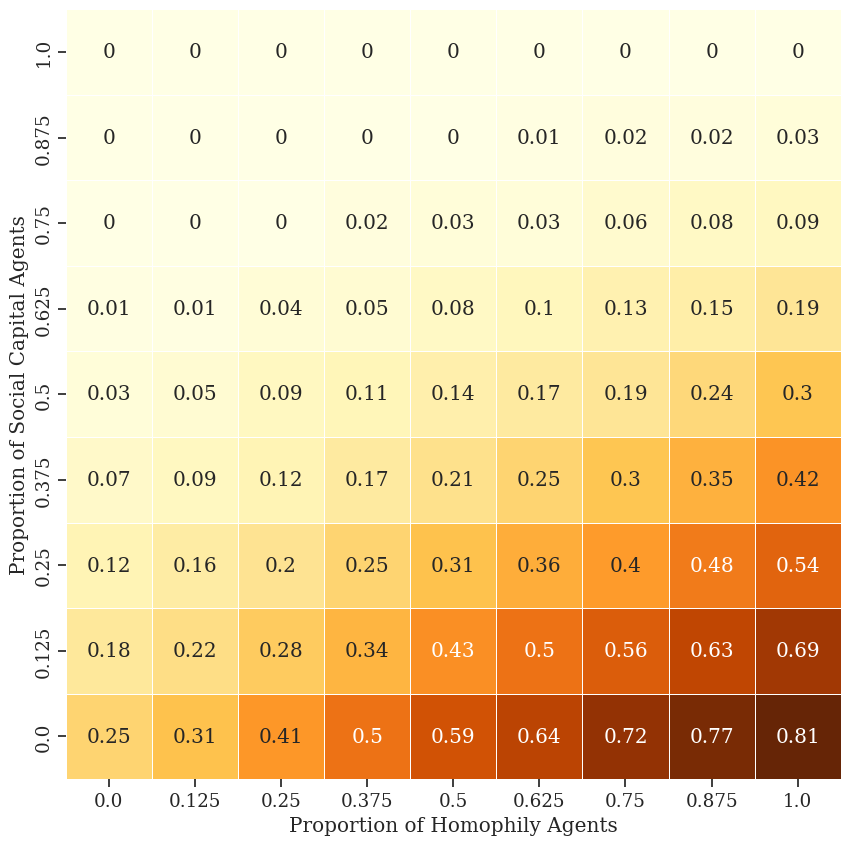

for dataset Clustering coefficient data max 0.81 data min 0.0
Betweeness centrality Gini coefficient corners 0.32 0.07 0.8 0.07


<Figure size 640x480 with 0 Axes>

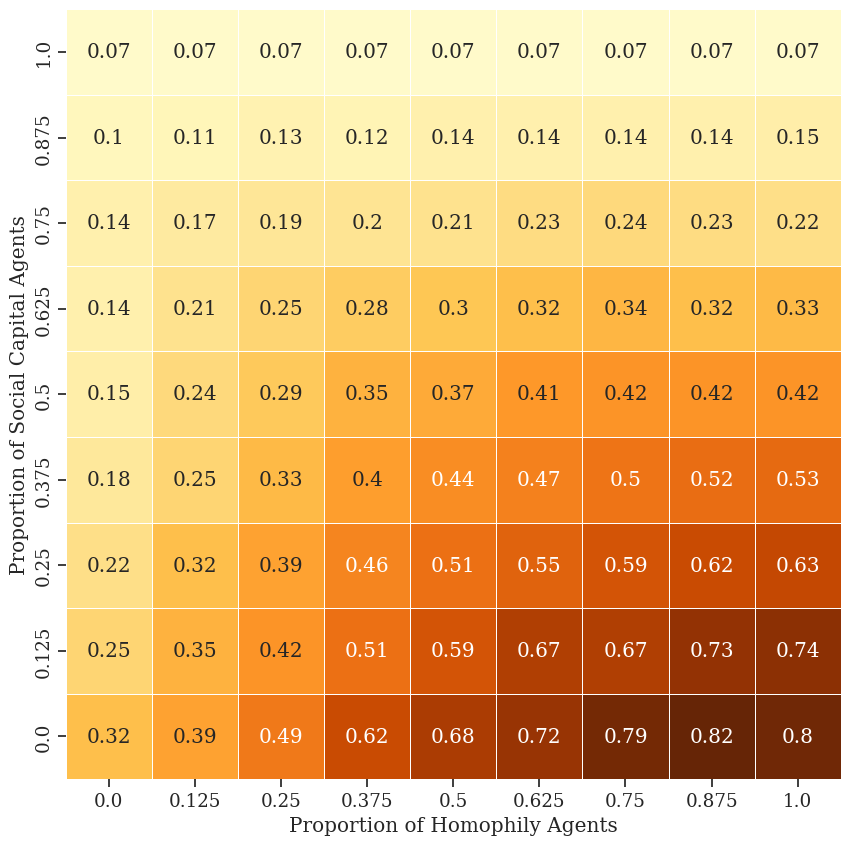

for dataset Betweeness centrality Gini coefficient data max 0.82 data min 0.07
Proportion in giant component corners 1.0 1.0 0.34 1.0


<Figure size 640x480 with 0 Axes>

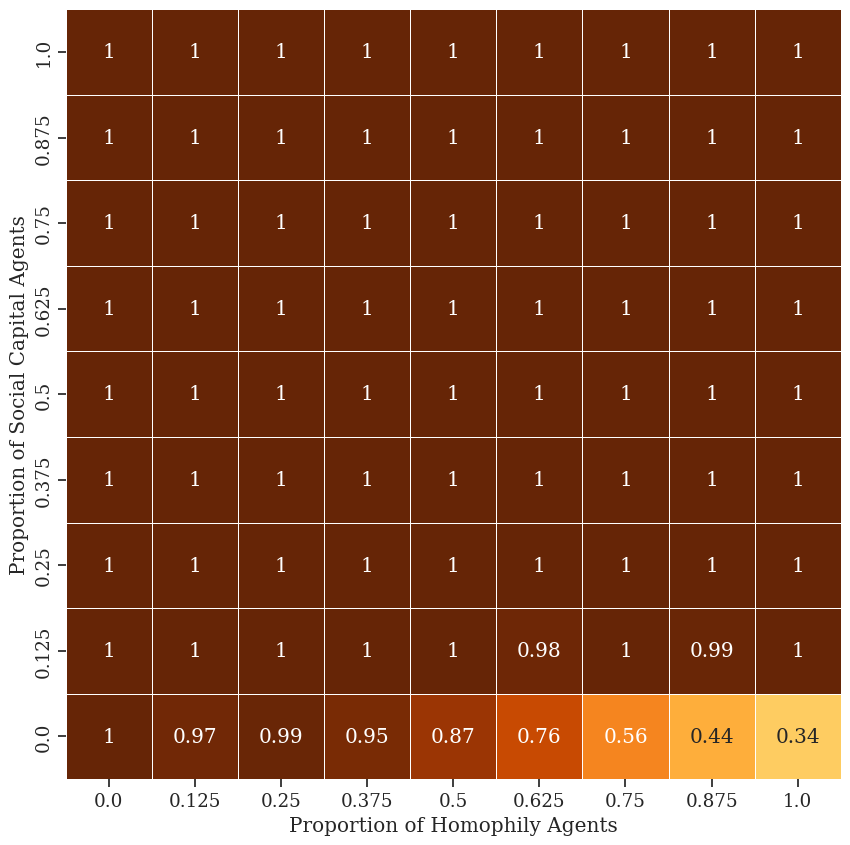

for dataset Proportion in giant component data max 1.0 data min 0.34
Number of components corners 1.1 1.0 5.9 1.0


<Figure size 640x480 with 0 Axes>

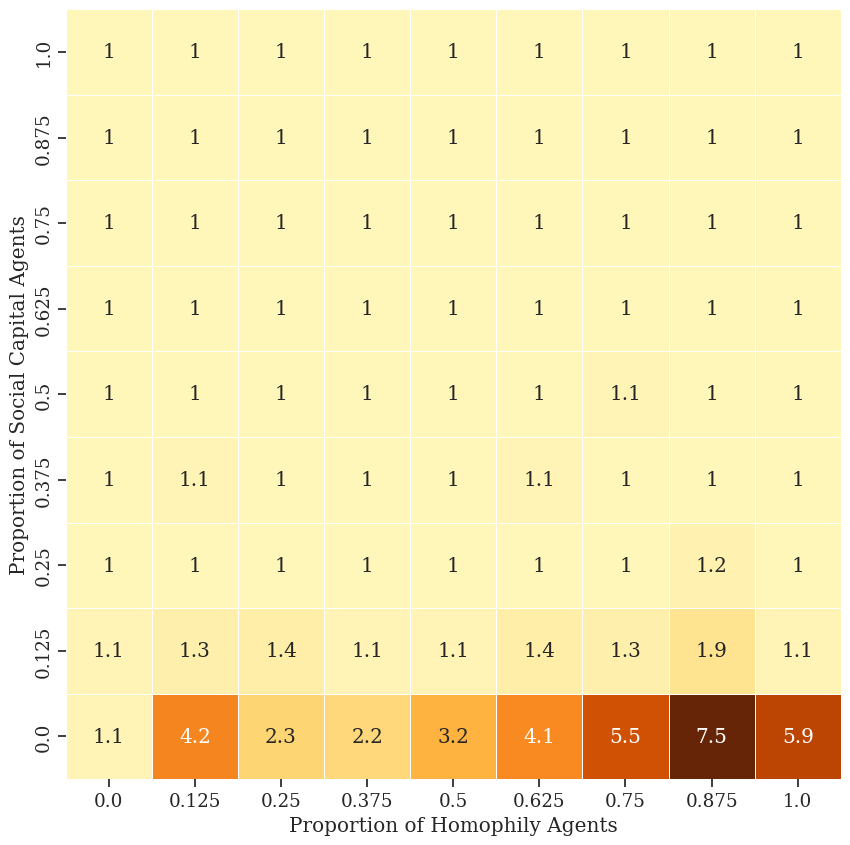

for dataset Number of components data max 7.5 data min 1.0
Modularity corners 0.54 0.25 0.88 0.25


<Figure size 640x480 with 0 Axes>

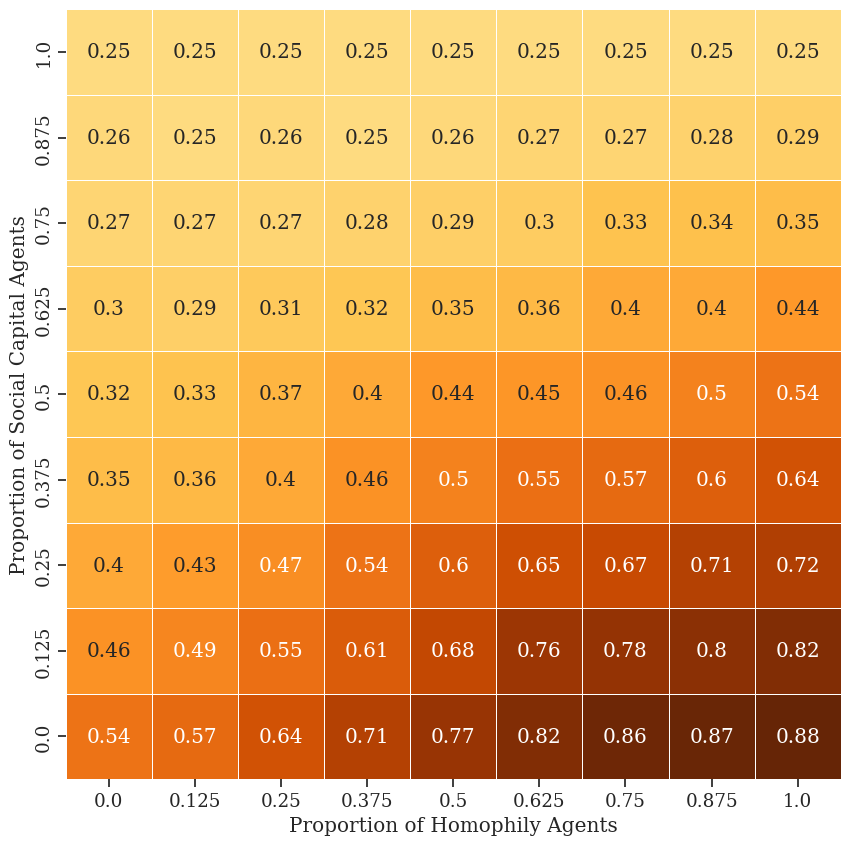

for dataset Modularity data max 0.88 data min 0.25


<Figure size 640x480 with 0 Axes>

In [24]:
metrics = [
'degree', 'deg_deg', 'deg_std', 'deg_gini', 'apl', 'diameter', 'cluster_coeff', 'centrality_gini', 'giant_prop', 'num_comp', 'modularity'
]
metric_names = [
'Average degree', 'Degree assortativity', 'Degree standard deviation', 'Degree Gini coefficient', 'Average path length', 'Diameter', 'Clustering coefficient', 'Betweeness centrality Gini coefficient', 'Proportion in giant component', 'Number of components', 'Modularity'
]

param_vals = np.linspace(0, 1, 9)
param_idx = list(range(9))
for mtr, mtr_name in zip(metrics, metric_names):
    mtr_arr = np.zeros((len(param_vals), len(param_vals)))
    for sc_i, ho_i in product(param_idx, param_idx):
        param_str = f'{param_vals[sc_i]} {param_vals[ho_i]}'
        mtr_arr[sc_i][ho_i] = round(float(stats_data[param_str][mtr]), 2)
    print(mtr_name, 'corners', mtr_arr[0][0], mtr_arr[-1][0], mtr_arr[0][-1], mtr_arr[-1][-1])

    mtr_min = 0
    if mtr == 'deg_deg':
        mtr_min = - 0.1
    plot_heat_map(mtr_arr, mtr_name, mtr_min, param_vals, param_vals)